In [1]:
# Standard imports
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Multiclass wrappers
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Metrics

# Useful tools for averaging cv results
import composable.records as rec

# Metrics to use on the test set
# metric(y_test, y_predict)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay



In [2]:
(olive_oil :=
 pl.read_csv("data/OliveOils.csv")
)

Area.name,palmitic,palmitoleic,strearic,oleic,linoleic,eicosanoic,linolenic
str,i64,i64,i64,i64,i64,i64,i64
"""North-Apulia""",1075,75,226,7823,672,36,60
"""North-Apulia""",1088,73,224,7709,781,31,61
"""North-Apulia""",911,54,246,8113,549,31,63
"""North-Apulia""",966,57,240,7952,619,50,78
"""North-Apulia""",1051,67,259,7771,672,50,80
…,…,…,…,…,…,…,…
"""West-Liguria""",1280,110,290,7490,790,10,10
"""West-Liguria""",1060,100,270,7740,810,10,10
"""West-Liguria""",1010,90,210,7720,970,0,0


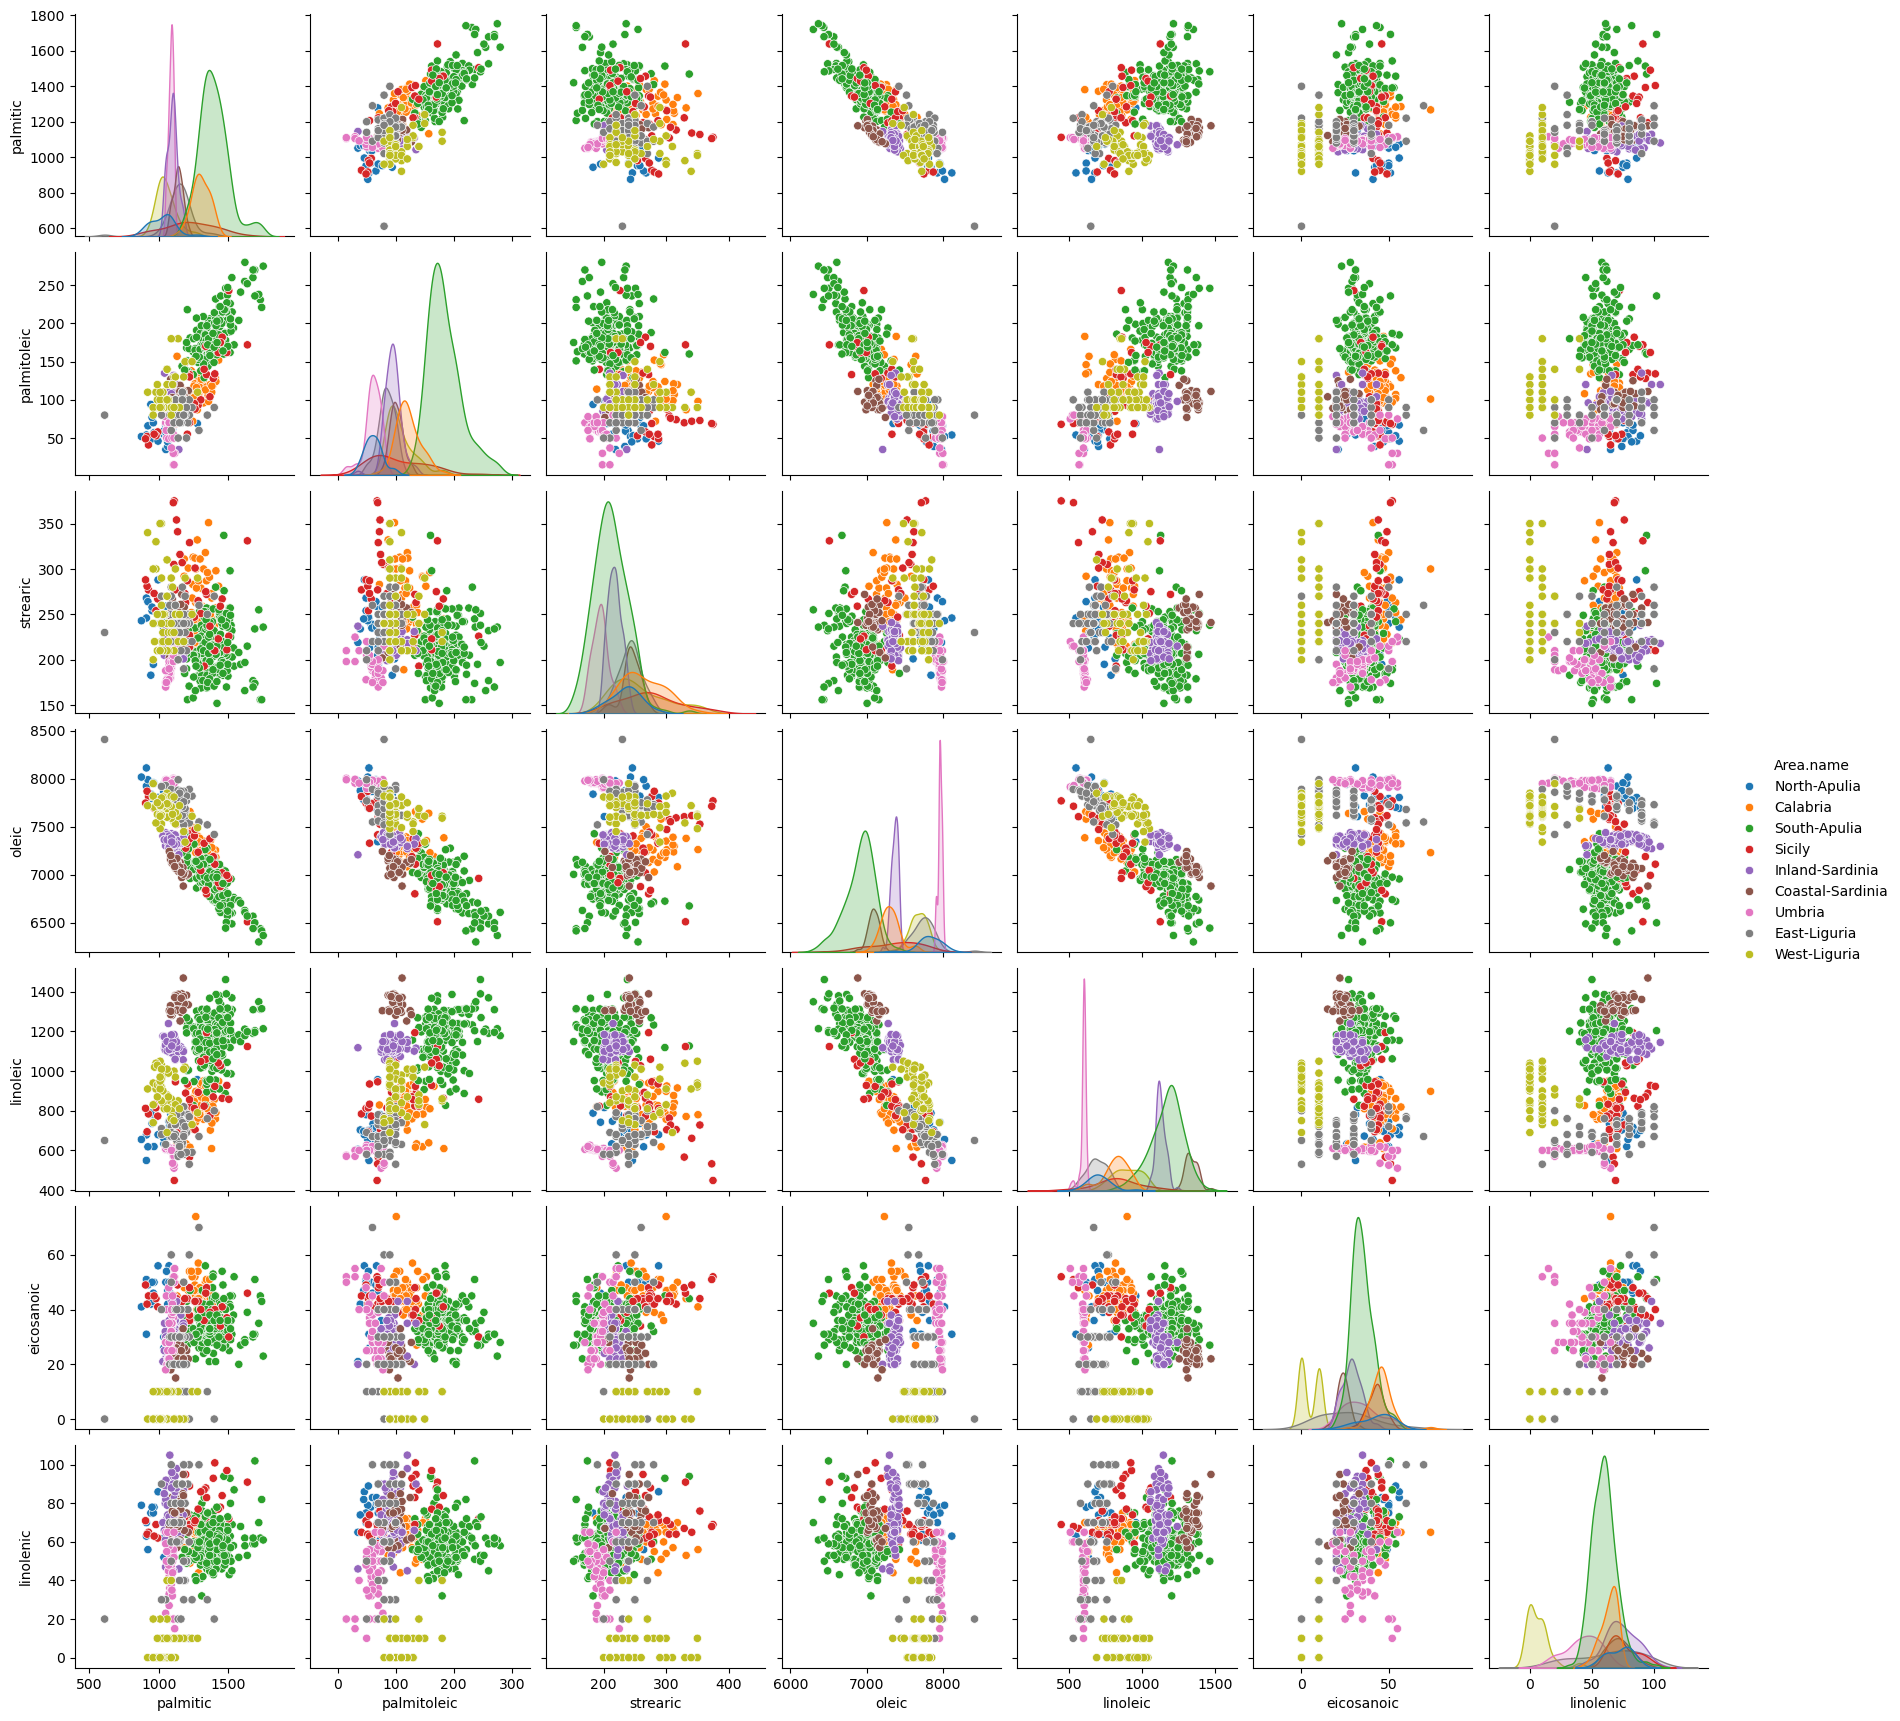

In [3]:
sns.pairplot(olive_oil.to_pandas(), hue = 'Area.name')

In [4]:
(X_oil :=
 olive_oil
 .drop('Area.name')
 .to_pandas()
)

,palmitic,palmitoleic,strearic,oleic,linoleic,eicosanoic,linolenic
0,1075,75,226,7823,672,36,60
1,1088,73,224,7709,781,31,61
2,911,54,246,8113,549,31,63
3,966,57,240,7952,619,50,78
4,1051,67,259,7771,672,50,80
...,...,...,...,...,...,...,...
567,1280,110,290,7490,790,10,10
568,1060,100,270,7740,810,10,10
569,1010,90,210,7720,970,0,0
570,990,120,250,7750,870,10,10


In [5]:
(y_oil :=
 olive_oil
 .select('Area.name')
 .to_pandas()
)

,Area.name
0,North-Apulia
1,North-Apulia
2,North-Apulia
3,North-Apulia
4,North-Apulia
...,...
567,West-Liguria
568,West-Liguria
569,West-Liguria
570,West-Liguria


In [6]:
X_train_oil, X_test_oil, y_train_oil, y_test_oil = train_test_split(X_oil, y_oil, test_size=0.3, random_state=42)

## Topic 1 - Target representation

**Options.**
1. Text label (who knew?),
2. Matrix of indicators, or
3. Sparse representation.

#### Option 1 - Text representation.

In [7]:
y_test_oil

,Area.name
512,East-Liguria
70,Calabria
131,South-Apulia
404,Inland-Sardinia
543,West-Liguria
...,...
69,Calabria
255,South-Apulia
177,South-Apulia
396,Inland-Sardinia


In [8]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_oil, y_train_oil.to_numpy().ravel())

log_reg.score(X_test_oil, y_test_oil.to_numpy().ravel())

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9069767441860465

In [9]:
log_reg.predict(X_test_oil)

array(['East-Liguria', 'Calabria', 'South-Apulia', 'Inland-Sardinia',
       'West-Liguria', 'South-Apulia', 'South-Apulia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Umbria', 'South-Apulia',
       'South-Apulia', 'East-Liguria', 'West-Liguria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Coastal-Sardinia',
       'Calabria', 'North-Apulia', 'Inland-Sardinia', 'Sicily',
       'West-Liguria', 'Calabria', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Calabria', 'South-Apulia', 'West-Liguria',
       'Umbria', 'West-Liguria', 'South-Apulia', 'Calabria',
       'East-Liguria', 'South-Apulia', 'North-Apulia', 'South-Apulia',
       'South-Apulia', 'Umbria', 'Inland-Sardinia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Umbria', 'Inland-Sardinia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Inland-Sardinia',
       'South-Apulia', 'South-Apulia', 'Calab

In [10]:
log_reg.score(X_test_oil, y_test_oil)

0.9069767441860465

In [11]:
(y_score := log_reg.predict_proba(X_test_oil)
)

array([[7.77353554e-06, 9.75983778e-70, 9.99835071e-01, ...,
        8.08515993e-11, 3.38598451e-05, 2.16438840e-08],
       [8.62108032e-01, 1.68318046e-57, 3.68669180e-05, ...,
        8.24265353e-06, 1.17768085e-17, 3.29535645e-08],
       [1.38281108e-07, 3.08901080e-13, 8.55135881e-15, ...,
        9.99985172e-01, 3.84155283e-29, 5.60201708e-06],
       ...,
       [2.69960342e-04, 2.57697414e-21, 3.67112696e-12, ...,
        9.99453140e-01, 3.84006896e-28, 2.65289111e-04],
       [1.42656531e-07, 4.55412949e-11, 1.58818591e-07, ...,
        2.25257676e-05, 1.37336351e-22, 9.22960164e-07],
       [5.13485548e-09, 1.40165463e-64, 2.04977591e-02, ...,
        1.07368468e-13, 9.78926319e-01, 4.00891813e-11]], shape=(172, 9))

In [12]:
scores = pl.DataFrame(y_score)
scores.columns = log_reg.classes_
scores

Calabria,Coastal-Sardinia,East-Liguria,Inland-Sardinia,North-Apulia,Sicily,South-Apulia,Umbria,West-Liguria
f64,f64,f64,f64,f64,f64,f64,f64,f64
0.000008,9.7598e-70,0.999835,6.3844e-19,0.000002,0.000121,8.0852e-11,0.000034,2.1644e-8
0.862108,1.6832e-57,0.000037,3.8940e-20,5.1623e-11,0.137847,0.000008,1.1777e-17,3.2954e-8
1.3828e-7,3.0890e-13,8.5514e-15,0.000009,4.7797e-17,1.0401e-8,0.999985,3.8416e-29,0.000006
1.7198e-7,0.000001,1.7623e-9,0.999684,7.0675e-10,0.000015,0.000286,2.7003e-27,0.000013
4.4233e-7,1.6280e-16,6.6805e-10,0.000978,6.6798e-10,2.7500e-8,0.000026,3.4151e-22,0.998996
…,…,…,…,…,…,…,…,…
0.925486,1.7668e-43,1.8360e-8,4.5591e-17,2.2746e-14,0.016178,0.058299,1.0407e-23,0.000037
0.00563,2.1334e-30,1.5432e-8,5.2171e-11,5.5949e-14,0.018048,0.97632,2.5586e-25,0.000002
0.00027,2.5770e-21,3.6711e-12,8.2961e-9,1.4224e-15,0.000012,0.999453,3.8401e-28,0.000265


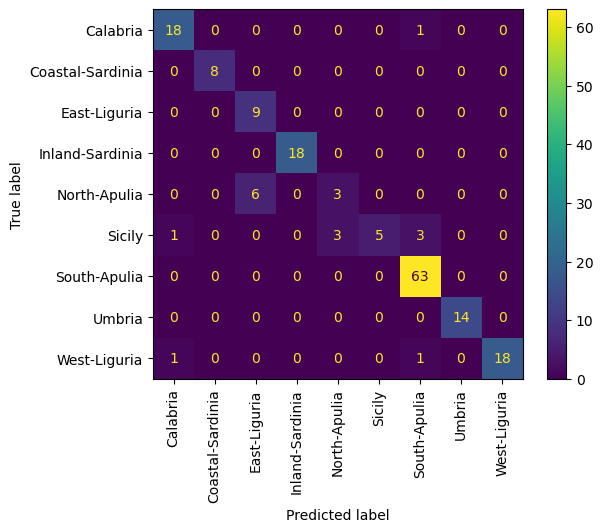

In [13]:
plt = ConfusionMatrixDisplay.from_estimator(log_reg, X_test_oil, y_test_oil, xticks_rotation='vertical')

## <font color="red"> Exercise 1 </font>

Pick to regions of interest then do each of the following:
1. Compute a sensitivity-like measurement by computing the row-wise proportion of correct predictions, and
2. Compute a positive-predictive-power-like measurement by computing the columns-wise proportion of correct predictions.
3. Interpret each metrix in the context of the problem.

 <font color = "orange">
 I picked calabria, Sicily, and Umbria
</font>

### Calabria
Sensitivity: .94  Positive Power: .95

The model excels at identifying Calabria oils with 94% sensitivity, catching nearly all genuine samples. Its 95% positive predictive power means predictions are highly reliable—when labeled as Calabria, it's almost always correct. This region has distinctive chemical features that the model learned very well.


### Sicily
Sensitivity: .42   Positive Power: 1

Sicily presents a different challenge: the model is extremely conservative with only 42% sensitivity, missing more than half of true Sicily samples. However, what it does predict as Sicily is always correct (100% positive predictive power). This suggests Sicily oils are difficult to distinguish from other regions, so the model only makes predictions when highly confident.

#### Option 2 - Indicator Matrix

**Notes.**

1. We can automate this process using `LabelBinarizer`
2. Classifiers like `LogisticRegression` must be wrapped in another class to allow this representation.
3. This output can be BIG, as it will be a $x\times k$ matrix for $n$ rows of $k$ unique classes.

In [14]:
lb = LabelBinarizer()
lb.fit_transform(y_oil)

(y_oil_ind := lb.transform(y_oil))

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(572, 9))

In [15]:
X_train_oil, X_test_oil, y_train_oil_ind, y_test_oil_ind = train_test_split(X_oil, y_oil_ind, test_size=0.3, random_state=42)

In [16]:
y_train_oil_ind, y_test_oil_ind

(array([[0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 1, 0, 0]], shape=(400, 9)),
 array([[0, 0, 1, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0]], shape=(172, 9)))

#### Option 3 - Sparse Representation

**Notes.**
1. This representation fixes the issue with the size of an indicator matrix, but becomes even more unreadable.
2. Also needs another class wrapper for classifiers like `LogisticRegression`.

In [17]:
?sparse.csr_matrix

Object `sparse.csr_matrix` not found.


In [18]:
from scipy import sparse
(y_oil_sparse := sparse.csr_matrix(y_oil_ind))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 572 stored elements and shape (572, 9)>

In [19]:
X_train_oil, X_test_oil, y_train_oil_sparse, y_test_oil_sparse = train_test_split(X_oil, y_oil_sparse, test_size=0.3, random_state=42)


In [20]:
y_train_oil_sparse, y_test_oil_sparse


(<Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 400 stored elements and shape (400, 9)>,
 <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 172 stored elements and shape (172, 9)>)

## Topic 2 - `OneVsRestClassifier`

**Notes.**
1. Makes one classifier per class,
2. Each trains "class k" VS "not class k"
3. Results in $k$ classifiers, one per $k$ unique classes.

In [21]:
(cls := OneVsRestClassifier(LogisticRegression(max_iter=1000))
)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


### Target representation - This classifier can be trained on all three target representations

#### Labels

In [22]:
cls_lbl = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_lbl.fit(X_train_oil, y_train_oil)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [23]:
cls_lbl.predict(X_test_oil)

array(['East-Liguria', 'Calabria', 'South-Apulia', 'Inland-Sardinia',
       'West-Liguria', 'South-Apulia', 'South-Apulia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Umbria', 'South-Apulia',
       'South-Apulia', 'East-Liguria', 'West-Liguria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Coastal-Sardinia',
       'Calabria', 'North-Apulia', 'Inland-Sardinia', 'Sicily',
       'West-Liguria', 'Calabria', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Calabria', 'South-Apulia', 'West-Liguria',
       'Umbria', 'West-Liguria', 'South-Apulia', 'Calabria',
       'East-Liguria', 'South-Apulia', 'North-Apulia', 'South-Apulia',
       'South-Apulia', 'Umbria', 'Inland-Sardinia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Umbria', 'Inland-Sardinia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Sicily', 'Inland-Sardinia',
       'South-Apulia', 'South-Apulia', 'Calabria', 

#### Indicator matrix

In [24]:
cls_ind = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_ind.fit(X_train_oil, y_train_oil_ind)


,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [25]:
(y_pred_ind :=
 cls_ind.predict(X_test_oil)
)

array([[0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]], shape=(172, 9))

In [26]:
lb.inverse_transform(y_pred_ind)

array(['East-Liguria', 'Calabria', 'South-Apulia', 'Calabria',
       'West-Liguria', 'South-Apulia', 'South-Apulia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Calabria', 'Calabria', 'Calabria',
       'East-Liguria', 'West-Liguria', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'Coastal-Sardinia', 'Calabria',
       'North-Apulia', 'Inland-Sardinia', 'Sicily', 'West-Liguria',
       'Calabria', 'South-Apulia', 'West-Liguria', 'South-Apulia',
       'Calabria', 'South-Apulia', 'West-Liguria', 'Umbria',
       'West-Liguria', 'South-Apulia', 'Calabria', 'East-Liguria',
       'South-Apulia', 'Calabria', 'South-Apulia', 'South-Apulia',
       'Umbria', 'Inland-Sardinia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'West-Liguria', 'South-Apulia',
       'Umbria', 'Calabria', 'Calabria', 'South-Apulia', 'South-Apulia',
       'Sicily', 'Inland-Sardinia', 'South-Apulia', 'South-Apulia',
       'Calabria', 'Sicily', 'Calabria', 'E

#### Sparse Matrix

In [27]:
cls_sparse = OneVsRestClassifier(LogisticRegression(max_iter=1000))
cls_sparse.fit(X_train_oil, y_train_oil_sparse)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [28]:
cls_sparse.predict(X_test_oil)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 166 stored elements and shape (172, 9)>

In [29]:
# Don't know how to inverse transform this :()

## Topic 3 - `OneVsOneClassifier`

**Notes.**
1. Needs to wrap a classifier class,
2. Builds one classifier per pair of unique classes,
3. Buillds a total of $\frac{n*(n-1)}{2}$ classifiers, and
4. Good for classifiers where training gets expensive with more data.

In [30]:
(cls_ovo := OneVsOneClassifier(LogisticRegression(max_iter=1000)))

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'


In [31]:
cls_ovo.fit(X_train_oil, y_train_oil)

cls_ovo.predict(X_test_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array(['East-Liguria', 'Calabria', 'South-Apulia', 'Inland-Sardinia',
       'West-Liguria', 'South-Apulia', 'South-Apulia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Umbria', 'South-Apulia',
       'West-Liguria', 'East-Liguria', 'West-Liguria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Coastal-Sardinia',
       'Calabria', 'North-Apulia', 'Inland-Sardinia', 'Sicily',
       'West-Liguria', 'Calabria', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Calabria', 'South-Apulia', 'West-Liguria',
       'Umbria', 'West-Liguria', 'South-Apulia', 'Calabria', 'Umbria',
       'South-Apulia', 'North-Apulia', 'South-Apulia', 'South-Apulia',
       'Umbria', 'Inland-Sardinia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'West-Liguria', 'South-Apulia',
       'Umbria', 'Inland-Sardinia', 'Calabria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'Inland-Sardinia', 'South-Apulia',
       'South-Apulia', 'Calabria', 

In [32]:
cls_ovo.score(X_test_oil, y_test_oil)

0.9069767441860465

In [33]:
cls_ovo.predict(X_test_oil)

array(['East-Liguria', 'Calabria', 'South-Apulia', 'Inland-Sardinia',
       'West-Liguria', 'South-Apulia', 'South-Apulia', 'Calabria',
       'South-Apulia', 'South-Apulia', 'Umbria', 'South-Apulia',
       'West-Liguria', 'East-Liguria', 'West-Liguria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'South-Apulia', 'Coastal-Sardinia',
       'Calabria', 'North-Apulia', 'Inland-Sardinia', 'Sicily',
       'West-Liguria', 'Calabria', 'South-Apulia', 'West-Liguria',
       'South-Apulia', 'Calabria', 'South-Apulia', 'West-Liguria',
       'Umbria', 'West-Liguria', 'South-Apulia', 'Calabria', 'Umbria',
       'South-Apulia', 'North-Apulia', 'South-Apulia', 'South-Apulia',
       'Umbria', 'Inland-Sardinia', 'South-Apulia', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'West-Liguria', 'South-Apulia',
       'Umbria', 'Inland-Sardinia', 'Calabria', 'South-Apulia',
       'South-Apulia', 'South-Apulia', 'Inland-Sardinia', 'South-Apulia',
       'South-Apulia', 'Calabria', 

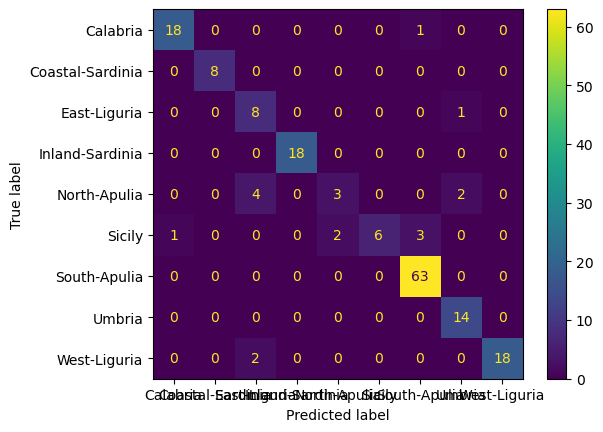

In [34]:
ConfusionMatrixDisplay.from_estimator(cls_ovo, X_test_oil, y_test_oil)

## <font color = 'red'> Exercise 2 </font>

For each of the classic classification methods, do the following

1. Fit the method to the training labels,
2. Get the score and confusion matrix for the test data.

Repeat that process when wrapping each classifier in
1. One vs rest, and
2. One vs one.

Finally, report on the best performing approach according to the score.

## Logistic regression

In [35]:
(log := LogisticRegression(max_iter=1000))
log.fit(X_train_oil, y_train_oil.to_numpy().ravel())

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
log.score(X_test_oil, y_test_oil)

0.9069767441860465

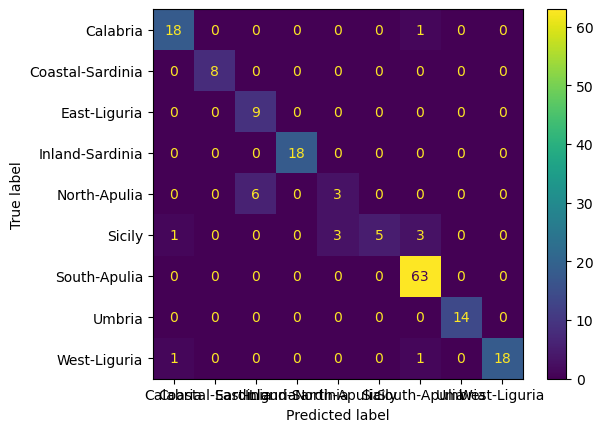

In [68]:
ConfusionMatrixDisplay.from_estimator(log, X_test_oil, y_test_oil)

In [69]:
(log_ovo := OneVsOneClassifier(LogisticRegression(max_iter=1000)))
log_ovo.fit(X_train_oil, y_train_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'


In [70]:
log_ovo.score(X_test_oil, y_test_oil)

0.9069767441860465

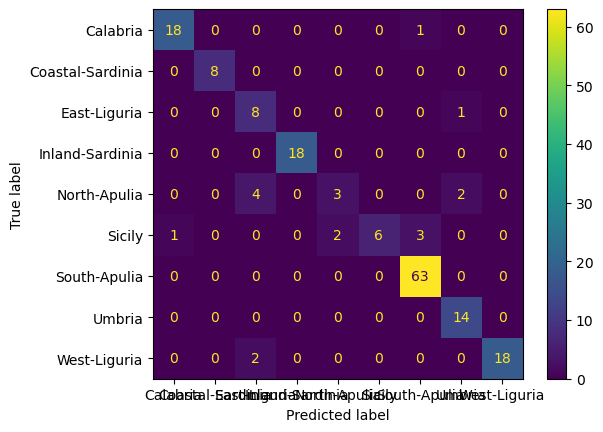

In [71]:
ConfusionMatrixDisplay.from_estimator(log_ovo, X_test_oil, y_test_oil)

In [72]:
(log_ovr := OneVsRestClassifier(LogisticRegression(max_iter=1000)))
log_ovr.fit(X_train_oil, y_train_oil)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [73]:
log_ovr.score(X_test_oil, y_test_oil)

0.9127906976744186

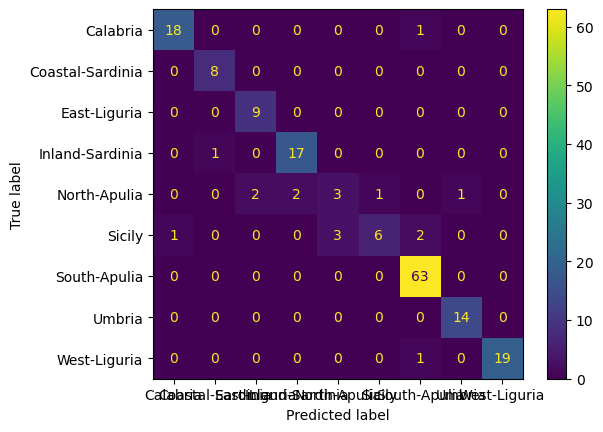

In [74]:
ConfusionMatrixDisplay.from_estimator(log_ovr, X_test_oil, y_test_oil)

## Bayes

In [75]:
(bayes := GaussianNB())
bayes.fit(X_train_oil, y_train_oil.to_numpy().ravel())

,priors,None
,var_smoothing,1e-09


In [76]:
bayes.score(X_test_oil, y_test_oil)

0.8895348837209303

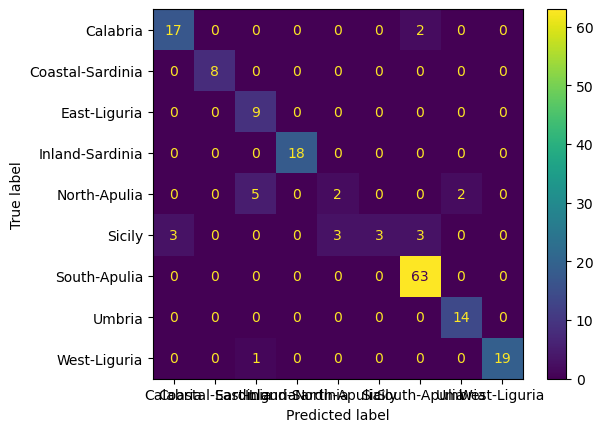

In [77]:
ConfusionMatrixDisplay.from_estimator(bayes, X_test_oil, y_test_oil)

In [78]:
(bayes_ovo := OneVsOneClassifier(GaussianNB()))
bayes_ovo.fit(X_train_oil, y_train_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,GaussianNB()
,n_jobs,None
,priors,None
,var_smoothing,1e-09


In [79]:
bayes_ovo.score(X_test_oil, y_test_oil)

0.8895348837209303

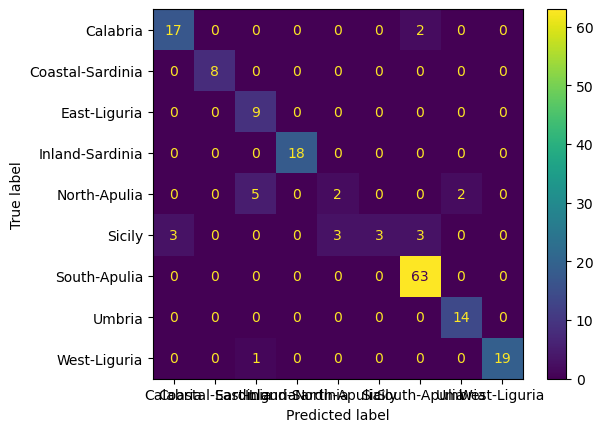

In [80]:
ConfusionMatrixDisplay.from_estimator(bayes_ovo, X_test_oil, y_test_oil)

In [81]:
(bayes_ovr := OneVsRestClassifier(GaussianNB()))
bayes_ovr.fit(X_train_oil, y_train_oil)

,estimator,GaussianNB()
,n_jobs,None
,verbose,0
,priors,None
,var_smoothing,1e-09


In [82]:
bayes_ovr.score(X_test_oil, y_test_oil)

0.8895348837209303

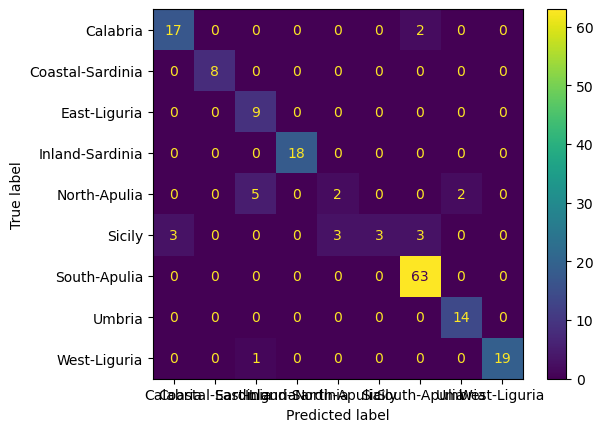

In [83]:
ConfusionMatrixDisplay.from_estimator(bayes_ovr, X_test_oil, y_test_oil)

## QDA

In [84]:
(QDA := QuadraticDiscriminantAnalysis())
QDA.fit(X_train_oil, y_train_oil.to_numpy().ravel())

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [85]:
QDA.score(X_test_oil, y_test_oil)

0.9418604651162791

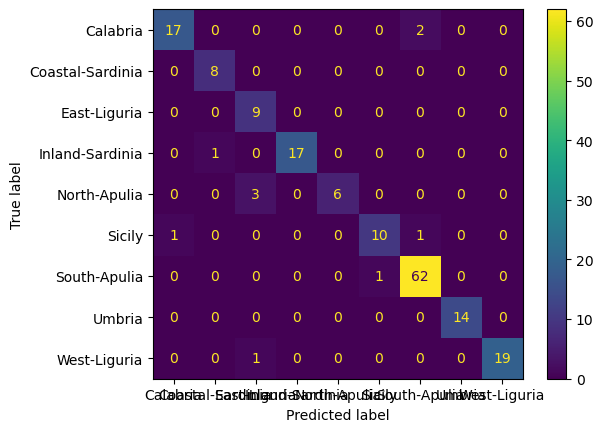

In [86]:
ConfusionMatrixDisplay.from_estimator(QDA, X_test_oil, y_test_oil)

In [87]:
(QDA_ovo := OneVsOneClassifier(QuadraticDiscriminantAnalysis()))
QDA_ovo.fit(X_train_oil, y_train_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,QuadraticDisc...nantAnalysis()
,n_jobs,None
,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [88]:
QDA_ovo.score(X_test_oil, y_test_oil)

0.9418604651162791

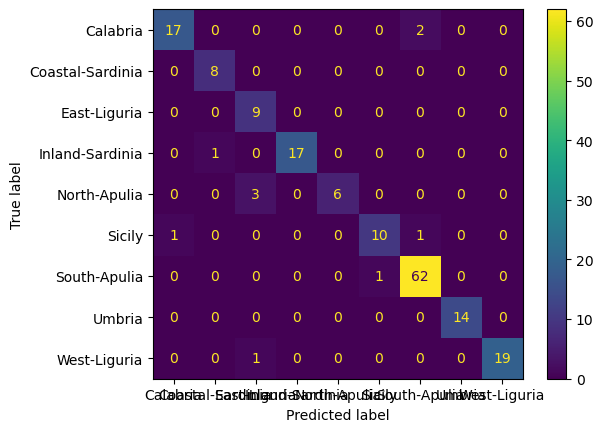

In [89]:
ConfusionMatrixDisplay.from_estimator(QDA_ovo, X_test_oil, y_test_oil)

In [90]:
(QDA_ovr := OneVsRestClassifier(QuadraticDiscriminantAnalysis()))
QDA_ovr.fit(X_train_oil, y_train_oil)

,estimator,QuadraticDisc...nantAnalysis()
,n_jobs,None
,verbose,0
,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [91]:
QDA_ovr.score(X_test_oil, y_test_oil)

0.9418604651162791

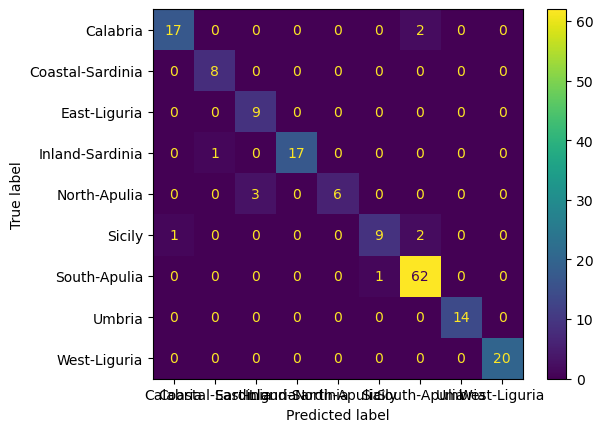

In [92]:
ConfusionMatrixDisplay.from_estimator(QDA_ovr, X_test_oil, y_test_oil)

## LDA

In [93]:
(LDA := LinearDiscriminantAnalysis())
LDA.fit(X_train_oil, y_train_oil.to_numpy().ravel())

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [94]:
LDA.score(X_test_oil, y_test_oil)

0.9127906976744186

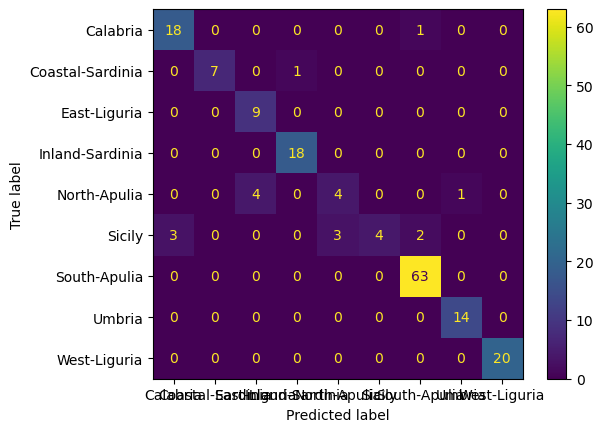

In [95]:
ConfusionMatrixDisplay.from_estimator(LDA, X_test_oil, y_test_oil)

In [96]:
(LDA_ovo := OneVsOneClassifier(QuadraticDiscriminantAnalysis()))
LDA_ovo.fit(X_train_oil, y_train_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,QuadraticDisc...nantAnalysis()
,n_jobs,None
,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [97]:
LDA_ovo.score(X_test_oil, y_test_oil)

0.9418604651162791

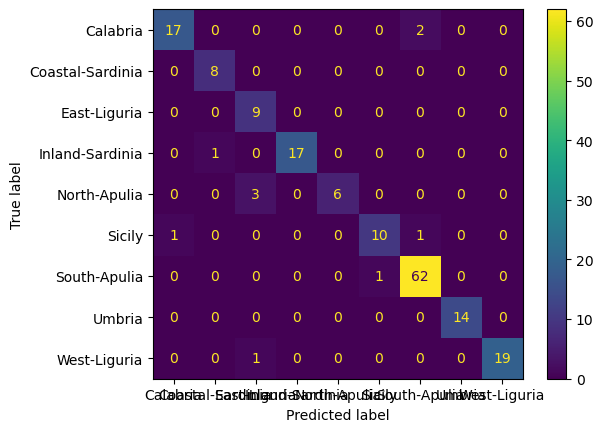

In [98]:
ConfusionMatrixDisplay.from_estimator(LDA_ovo, X_test_oil, y_test_oil)

In [99]:
(LDA_ovr := OneVsRestClassifier(QuadraticDiscriminantAnalysis()))
LDA_ovr.fit(X_train_oil, y_train_oil)

,estimator,QuadraticDisc...nantAnalysis()
,n_jobs,None
,verbose,0
,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [100]:
LDA_ovr.score(X_test_oil, y_test_oil)

0.9418604651162791

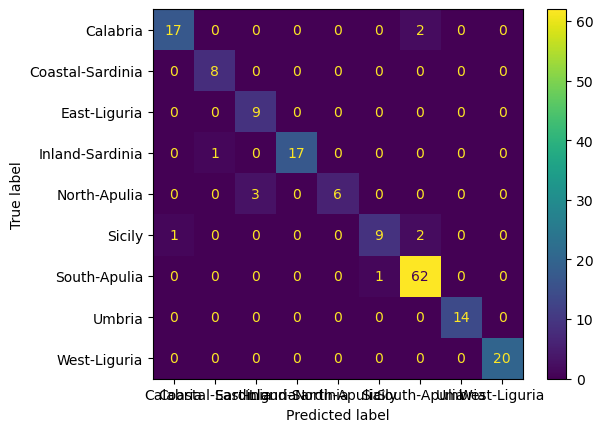

In [101]:
ConfusionMatrixDisplay.from_estimator(LDA_ovr, X_test_oil, y_test_oil)

## kNN

In [102]:
kNN = KNeighborsClassifier()
grid_knn = {"n_neighbors": list(range(3, 12, 2))}
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)


# Use a multiclass-friendly scoring metric
grid_search_knn = GridSearchCV(kNN, grid_knn, cv=folds, scoring="accuracy")
grid_search_knn.fit(X_train_oil, y_train_oil.to_numpy().ravel())

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [103]:
grid_search_knn.score(X_test_oil, y_test_oil.to_numpy().ravel())

0.872093023255814

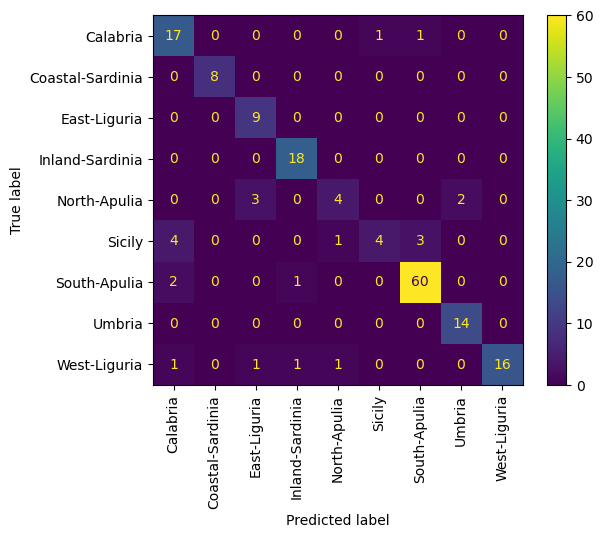

In [104]:
ConfusionMatrixDisplay.from_estimator(
    grid_search_knn, X_test_oil, y_test_oil, xticks_rotation="vertical"
)

In [105]:
knn_ovo = OneVsOneClassifier(KNeighborsClassifier())
grid_knn_ovo = {"estimator__n_neighbors": list(range(3, 12, 2))}
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

grid_search_knn_ovo = GridSearchCV(knn_ovo, grid_knn_ovo, cv=folds, scoring="accuracy")
grid_search_knn_ovo.fit(X_train_oil, y_train_oil)

grid_search_knn_ovo.score(X_test_oil, y_test_oil)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\validation.py:1406: DataConve

0.8662790697674418

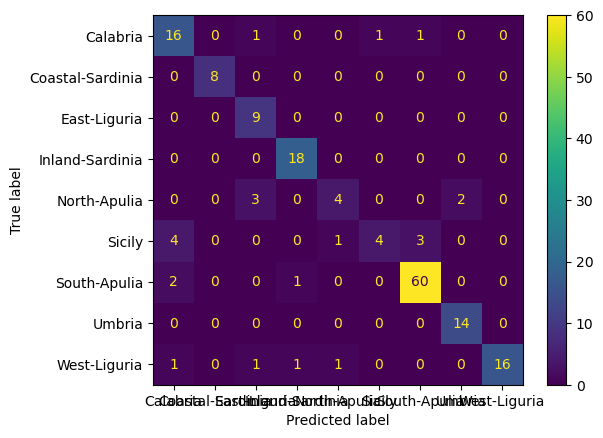

In [106]:
ConfusionMatrixDisplay.from_estimator(grid_search_knn_ovo, X_test_oil, y_test_oil)

In [107]:
knn_ovr = OneVsRestClassifier(KNeighborsClassifier())
grid_knn_ovr = {"estimator__n_neighbors": list(range(3, 12, 2))}
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

grid_search_knn_ovr = GridSearchCV(knn_ovr, grid_knn_ovr, cv=folds, scoring="accuracy")
grid_search_knn_ovr.fit(X_train_oil, y_train_oil)

grid_search_knn_ovr.score(X_test_oil, y_test_oil)

0.877906976744186

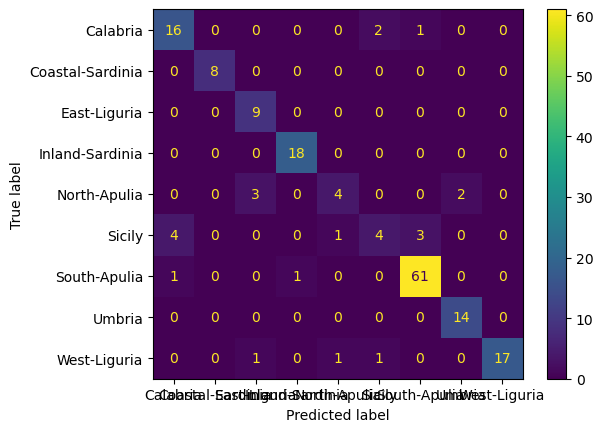

In [108]:
ConfusionMatrixDisplay.from_estimator(grid_search_knn_ovr, X_test_oil, y_test_oil)

<font color="orange">
Winning model(s) (highest score = 0.9419):
QDA, QDA (OvO), QDA (OvR), LDA (OvO), and LDA (OvR)

Top result was a tie at 0.9419, showing that QDA and LDA with multiclass decomposition were the strongest overall performers.
QDA was unaffected by OvO/OvR, which suggests the base QDA setup already captured class separation well.
LDA improved with both OvO and OvR compared with baseline LDA, indicating decomposition helped with multiclass boundaries.
Logistic Regression improved with OvR, which is a common pattern for linear classifiers in multiclass settings.
GaussianNB showed little to no change with OvO/OvR, so decomposition did not overcome its distributional assumptions.
kNN performed slightly worse with OvO/OvR than the tuned baseline kNN, likely due to extra pairwise/binary decision complexity.
Overall takeaway: OvO/OvR helped most for linear models (especially LDA), but offered limited benefit when the base model was already strong (QDA) or assumption-limited (GaussianNB).</font>